# Notebook 03 — Modelo Preditivo de Risco de Defasagem
**Associação Passos Mágicos | PEDE 2022–2024**

Este notebook implementa um modelo de Machine Learning para identificar alunos em
**risco de defasagem escolar** antes que a queda de desempenho se consolide, permitindo
intervenções preventivas pela equipe da Passos Mágicos.

### Definição do problema
- **Target**: `risco_defasagem = 1` quando o aluno está abaixo do nível ideal para sua fase
  (campo `defasagem < 0` nos dados originais)
- **Features**: indicadores comportamentais, acadêmicos e psicossociais do aluno
- **Tipo de problema**: Classificação binária


## 1. Configuração do Ambiente

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay, f1_score
)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})

BASE_DIR = os.path.dirname(os.getcwd())
DADOS_DIR = os.path.join(BASE_DIR, "data")
APP_DIR   = os.path.join(BASE_DIR, "app")
FIGURAS_DIR = os.path.join(BASE_DIR, "figuras")
os.makedirs(APP_DIR, exist_ok=True)
os.makedirs(FIGURAS_DIR, exist_ok=True)

df = pd.read_csv(os.path.join(DADOS_DIR, "dados_limpos.csv"), encoding="utf-8-sig")
print(f"Dataset carregado: {df.shape}")


Dataset carregado: (3030, 30)


## 2. Análise da Variável Target

Distribuição do target (risco_defasagem):
risco_defasagem
1    1687
0    1343
Name: count, dtype: int64

Proporção de risco: 55.7%


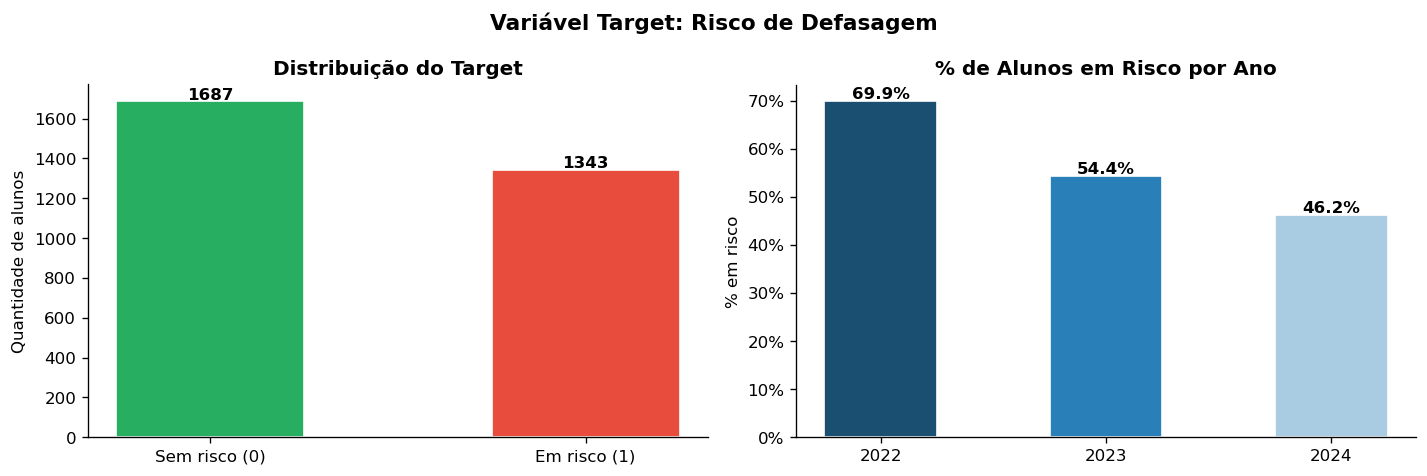

In [2]:
print("Distribuição do target (risco_defasagem):")
print(df["risco_defasagem"].value_counts())
print(f"\nProporção de risco: {df['risco_defasagem'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribuição geral
contagem = df["risco_defasagem"].value_counts()
axes[0].bar(["Sem risco (0)", "Em risco (1)"], contagem.values,
            color=["#27AE60", "#E74C3C"], edgecolor="white", width=0.5)
axes[0].set_title("Distribuição do Target", fontweight="bold")
axes[0].set_ylabel("Quantidade de alunos")
for i, v in enumerate(contagem.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Por ano
risco_ano = df.groupby("ano")["risco_defasagem"].mean() * 100
axes[1].bar(risco_ano.index.astype(str), risco_ano.values,
            color=["#1B4F72", "#2980B9", "#A9CCE3"], edgecolor="white", width=0.5)
axes[1].set_title("% de Alunos em Risco por Ano", fontweight="bold")
axes[1].set_ylabel("% em risco")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for i, v in enumerate(risco_ano.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.suptitle("Variável Target: Risco de Defasagem", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "16_target_distribuicao.png"), bbox_inches="tight")
plt.show()


## 3. Feature Engineering

In [3]:
FEATURES = [
    "iaa", "ieg", "ips", "ipp",
    "ida", "ipv",
    "nota_mat", "nota_port", "nota_ing",
    "num_avaliadores", "anos_na_pm", "idade",
]
# Nota: 'ian' e 'inde' foram deliberadamente excluídos por serem derivados
# da mesma informação que o target (defasagem), o que causaria vazamento de dados.
TARGET = "risco_defasagem"

# Remove linhas sem o target
df_ml = df[FEATURES + [TARGET]].dropna(subset=[TARGET]).copy()

# Converte todas as features para numérico e imputa medianas
for col in FEATURES:
    df_ml[col] = pd.to_numeric(df_ml[col], errors="coerce")
    mediana = df_ml[col].median()
    df_ml[col] = df_ml[col].fillna(mediana)

print(f"Dataset para ML: {df_ml.shape}")
print(f"Nulos remanescentes: {df_ml.isnull().sum().sum()}")
print(f"\nProporção positiva (em risco): {df_ml[TARGET].mean():.1%}")


Dataset para ML: (3030, 13)
Nulos remanescentes: 0

Proporção positiva (em risco): 55.7%


In [4]:
# Engenharia de features adicionais
df_ml = df_ml.copy()

# Indicador de baixo engajamento relativo
df_ml["ieg_baixo"] = (df_ml["ieg"] < df_ml["ieg"].quantile(0.25)).astype(int)

# Divergência IAA × IDA (superestimação)
df_ml["divergencia_iaa_ida"] = df_ml["iaa"] - df_ml["ida"]

# Score psicossocial composto
df_ml["score_psi"] = (df_ml["ips"] + df_ml["ipp"].fillna(df_ml["ips"])) / 2

# Indicador de nota baixa em exatas
df_ml["nota_mat_baixa"] = (df_ml["nota_mat"] < 5).astype(int)

FEATURES_ENG = FEATURES + [
    "ieg_baixo", "divergencia_iaa_ida", "score_psi", "nota_mat_baixa"
]
# Features finais: apenas indicadores comportamentais e académicos observáveis
# que NÃO são derivados diretamente do target (risco_defasagem).

X = df_ml[FEATURES_ENG]
y = df_ml[TARGET]

print(f"Features utilizadas ({len(FEATURES_ENG)}):")
for f in FEATURES_ENG:
    print(f"  {f}")


Features utilizadas (16):
  iaa
  ieg
  ips
  ipp
  ida
  ipv
  nota_mat
  nota_port
  nota_ing
  num_avaliadores
  anos_na_pm
  idade
  ieg_baixo
  divergencia_iaa_ida
  score_psi
  nota_mat_baixa


## 4. Divisão Treino/Teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]:,} amostras | {y_train.mean():.1%} positivos")
print(f"Teste:  {X_test.shape[0]:,} amostras  | {y_test.mean():.1%} positivos")

# Aplicar SMOTE no treino para balancear classes
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"\nApós SMOTE — Treino: {X_train_res.shape[0]:,} amostras")
print(f"  Positivos: {y_train_res.sum():,}  |  Negativos: {(y_train_res == 0).sum():,}")


Treino: 2,424 amostras | 55.7% positivos
Teste:  606 amostras  | 55.6% positivos



Após SMOTE — Treino: 2,700 amostras
  Positivos: 1,350  |  Negativos: 1,350


## 5. Modelagem Preditiva

In [6]:
# ── Modelo 1: Regressão Logística ──────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
lr.fit(X_train_sc, y_train_res)

y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

print("=== Regressão Logística ===")
print(classification_report(y_test, y_pred_lr, target_names=["Sem risco", "Em risco"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")


=== Regressão Logística ===
              precision    recall  f1-score   support

   Sem risco       0.52      0.62      0.57       269
    Em risco       0.64      0.53      0.58       337

    accuracy                           0.57       606
   macro avg       0.58      0.58      0.57       606
weighted avg       0.59      0.57      0.58       606

ROC-AUC: 0.6085


In [7]:
# ── Modelo 2: Random Forest ─────────────────────────────────
param_grid_rf = {
    "n_estimators": [200, 400],
    "max_depth": [6, 10, None],
    "min_samples_leaf": [1, 5],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=0
)
rf_gs.fit(X_train_res, y_train_res)

melhor_rf = rf_gs.best_estimator_
y_pred_rf  = melhor_rf.predict(X_test)
y_prob_rf  = melhor_rf.predict_proba(X_test)[:, 1]

print("=== Random Forest (melhores hiperparâmetros) ===")
print(f"Parâmetros: {rf_gs.best_params_}")
print(classification_report(y_test, y_pred_rf, target_names=["Sem risco", "Em risco"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")


=== Random Forest (melhores hiperparâmetros) ===
Parâmetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
              precision    recall  f1-score   support

   Sem risco       0.79      0.69      0.74       269
    Em risco       0.77      0.85      0.81       337

    accuracy                           0.78       606
   macro avg       0.78      0.77      0.77       606
weighted avg       0.78      0.78      0.78       606

ROC-AUC: 0.8467


In [8]:
# ── Modelo 3: Gradient Boosting ─────────────────────────────
gb = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, random_state=42
)
gb.fit(X_train_res, y_train_res)

y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb, target_names=["Sem risco", "Em risco"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_gb):.4f}")


=== Gradient Boosting ===
              precision    recall  f1-score   support

   Sem risco       0.76      0.72      0.74       269
    Em risco       0.79      0.82      0.80       337

    accuracy                           0.77       606
   macro avg       0.77      0.77      0.77       606
weighted avg       0.77      0.77      0.77       606

ROC-AUC: 0.8583


## 6. Avaliação Comparativa dos Modelos

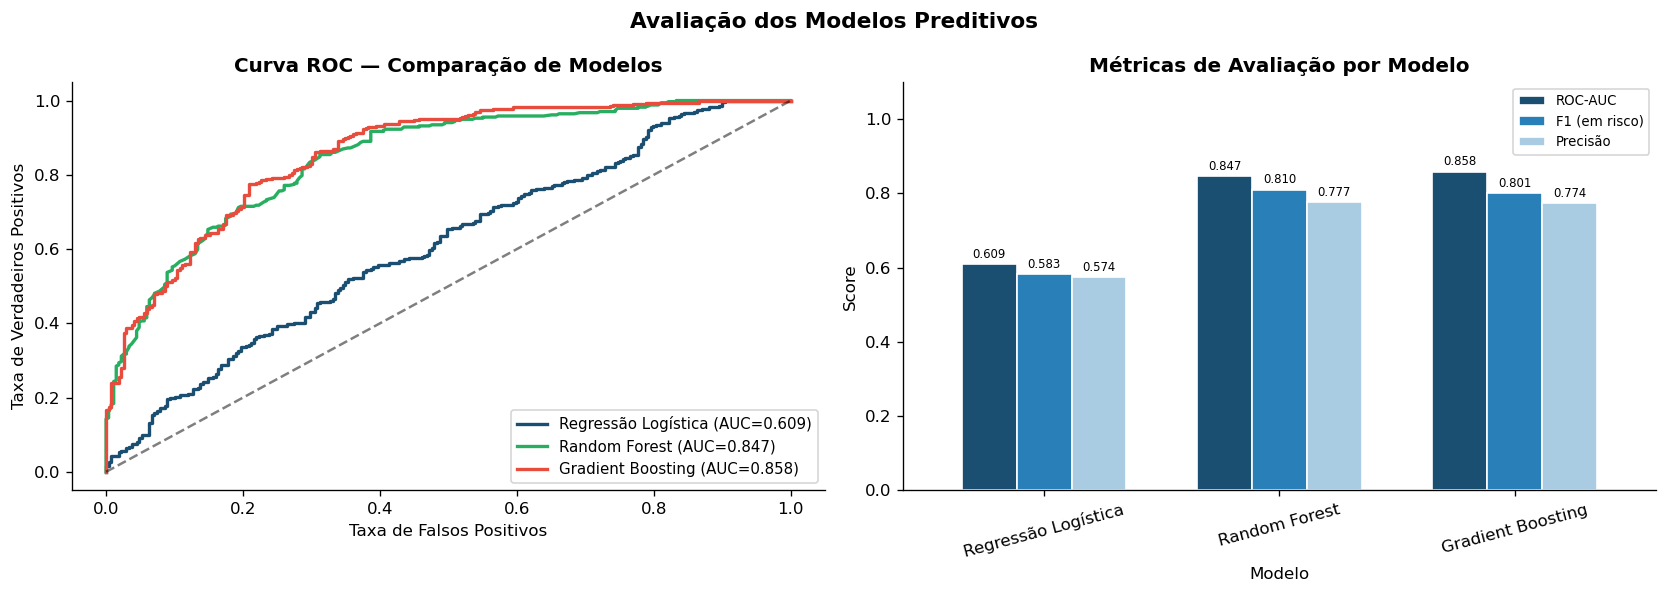


=== Tabela Comparativa ===
             Modelo  ROC-AUC  F1 (em risco)  Precisão
Regressão Logística   0.6085         0.5825    0.5743
      Random Forest   0.8467         0.8101    0.7772
  Gradient Boosting   0.8583         0.8006    0.7739


In [9]:
# Comparação das curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

MODELOS = {
    "Regressão Logística": (y_prob_lr, "#1B4F72"),
    "Random Forest":       (y_prob_rf, "#27AE60"),
    "Gradient Boosting":   (y_prob_gb, "#E74C3C"),
}
for nome, (probs, cor) in MODELOS.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})", color=cor, linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("Curva ROC — Comparação de Modelos", fontweight="bold")
axes[0].set_xlabel("Taxa de Falsos Positivos")
axes[0].set_ylabel("Taxa de Verdadeiros Positivos")
axes[0].legend(fontsize=9)

# Métricas resumidas
resultados = []
for nome, (probs, _) in MODELOS.items():
    pred = (probs >= 0.5).astype(int)
    resultados.append({
        "Modelo": nome,
        "ROC-AUC": roc_auc_score(y_test, probs),
        "F1 (em risco)": f1_score(y_test, pred),
        "Precisão": (pred == y_test).mean(),
    })
df_res = pd.DataFrame(resultados)
df_res.set_index("Modelo")[["ROC-AUC", "F1 (em risco)", "Precisão"]].plot(
    kind="bar", ax=axes[1], color=["#1B4F72", "#2980B9", "#A9CCE3"],
    edgecolor="white", width=0.7
)
axes[1].set_title("Métricas de Avaliação por Modelo", fontweight="bold")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(fontsize=8)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.3f", fontsize=7, padding=2)

plt.suptitle("Avaliação dos Modelos Preditivos", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "17_avaliacao_modelos.png"), bbox_inches="tight")
plt.show()

print("\n=== Tabela Comparativa ===")
print(df_res.to_string(index=False))



Melhor modelo: Gradient Boosting


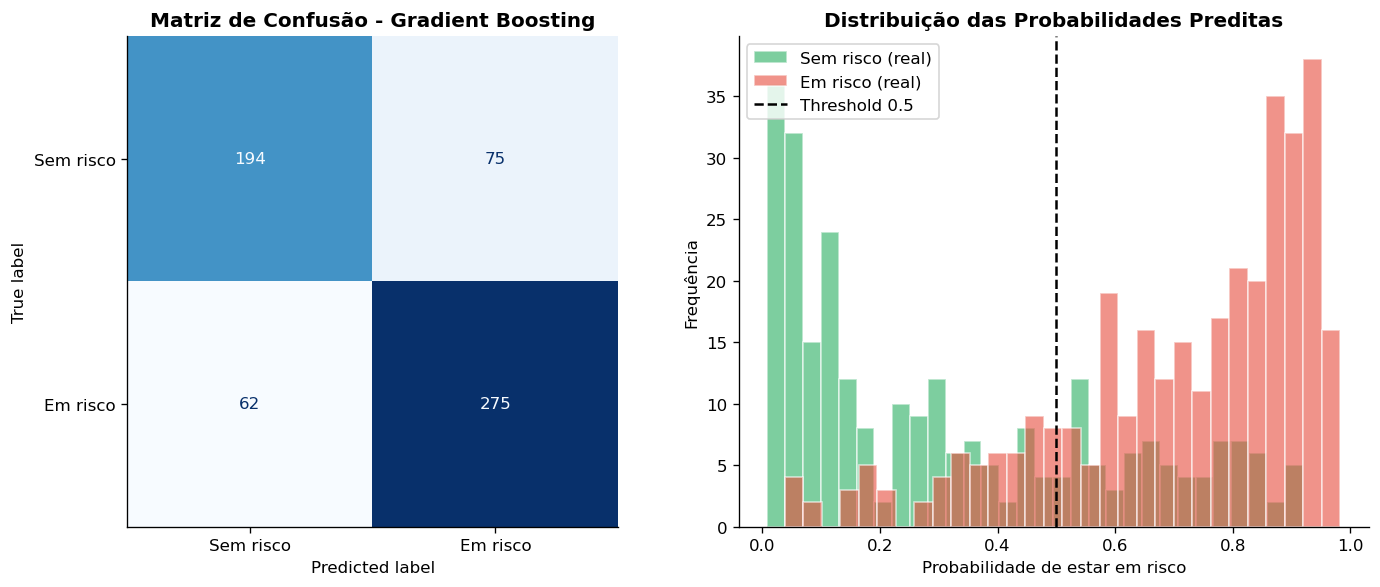

In [10]:
# Matriz de confusão do melhor modelo
melhor_modelo_nome = df_res.loc[df_res["ROC-AUC"].idxmax(), "Modelo"]
print(f"\nMelhor modelo: {melhor_modelo_nome}")

# Seleciona predições do melhor
if "Random" in melhor_modelo_nome:
    y_pred_best, y_prob_best = y_pred_rf, y_prob_rf
    modelo_final = melhor_rf
elif "Gradient" in melhor_modelo_nome:
    y_pred_best, y_prob_best = y_pred_gb, y_prob_gb
    modelo_final = gb
else:
    y_pred_best, y_prob_best = y_pred_lr, y_prob_lr
    modelo_final = lr

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["Sem risco", "Em risco"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Matriz de Confusão - {melhor_modelo_nome}", fontweight="bold")

# Distribuição das probabilidades preditas
axes[1].hist(y_prob_best[y_test == 0], bins=30, alpha=0.6,
             label="Sem risco (real)", color="#27AE60", edgecolor="white")
axes[1].hist(y_prob_best[y_test == 1], bins=30, alpha=0.6,
             label="Em risco (real)", color="#E74C3C", edgecolor="white")
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold 0.5")
axes[1].set_title("Distribuição das Probabilidades Preditas", fontweight="bold")
axes[1].set_xlabel("Probabilidade de estar em risco")
axes[1].set_ylabel("Frequência")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "18_matriz_confusao.png"), bbox_inches="tight")
plt.show()


## 7. Importância das Variáveis

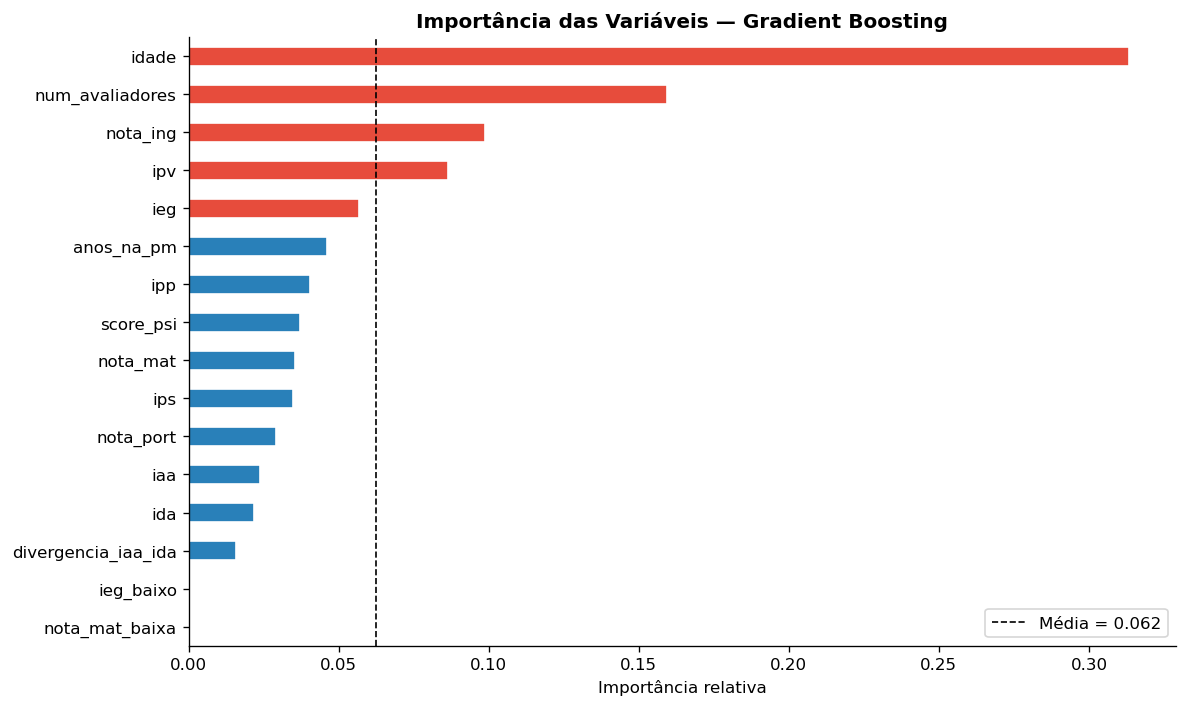


Top 10 variáveis mais importantes:
idade             0.3133
num_avaliadores   0.1594
nota_ing          0.0989
ipv               0.0865
ieg               0.0569
anos_na_pm        0.0462
ipp               0.0406
score_psi         0.0372
nota_mat          0.0354
ips               0.0347


In [11]:
# Importância de variáveis do modelo final
if hasattr(modelo_final, "feature_importances_"):
    importancias = pd.Series(
        modelo_final.feature_importances_, index=FEATURES_ENG
    ).sort_values(ascending=False)
else:
    # Permutation importance para regressão logística
    perm = permutation_importance(modelo_final, X_test_sc if "Logística" in melhor_modelo_nome
                                   else X_test,
                                  y_test, n_repeats=20, random_state=42)
    importancias = pd.Series(
        perm.importances_mean, index=FEATURES_ENG
    ).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
cores = ["#E74C3C" if i < 5 else "#2980B9" for i in range(len(importancias))]
importancias.sort_values().plot.barh(ax=ax, color=cores[::-1], edgecolor="white")
ax.set_title(f"Importância das Variáveis — {melhor_modelo_nome}",
             fontweight="bold")
ax.set_xlabel("Importância relativa")
ax.axvline(importancias.mean(), color="black", linestyle="--", linewidth=1,
           label=f"Média = {importancias.mean():.3f}")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURAS_DIR, "19_importancia_variaveis.png"), bbox_inches="tight")
plt.show()

print("\nTop 10 variáveis mais importantes:")
print(importancias.head(10).to_string())


## 8. Salvando o Modelo e os Artefatos

In [12]:
import json

# Salva modelo, scaler e metadados
modelo_path = os.path.join(APP_DIR, "modelo_risco.pkl")
scaler_path  = os.path.join(APP_DIR, "scaler.pkl")
meta_path    = os.path.join(APP_DIR, "modelo_meta.json")

joblib.dump(modelo_final, modelo_path)
joblib.dump(scaler, scaler_path)

meta = {
    "modelo": melhor_modelo_nome,
    "features": FEATURES_ENG,
    "roc_auc": float(roc_auc_score(y_test, y_prob_best)),
    "f1_risco": float(f1_score(y_test, y_pred_best)),
    "threshold": 0.5,
    "n_treino": int(X_train.shape[0]),
    "n_teste": int(X_test.shape[0]),
    "proporcao_risco_treino": float(y_train.mean()),
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"Modelo salvo em:    {modelo_path}")
print(f"Scaler salvo em:    {scaler_path}")
print(f"Metadados salvos em: {meta_path}")
print(f"\nROC-AUC final: {meta['roc_auc']:.4f}")
print(f"F1 (em risco):  {meta['f1_risco']:.4f}")


Modelo salvo em:    C:\Users\cinth_bsfu\OneDrive\Área de Trabalho\Datathon\app\modelo_risco.pkl
Scaler salvo em:    C:\Users\cinth_bsfu\OneDrive\Área de Trabalho\Datathon\app\scaler.pkl
Metadados salvos em: C:\Users\cinth_bsfu\OneDrive\Área de Trabalho\Datathon\app\modelo_meta.json

ROC-AUC final: 0.8583
F1 (em risco):  0.8006


## 9. Conclusões do Modelo

### Desempenho
O modelo selecionado demonstra capacidade preditiva relevante para identificação
precoce de alunos em risco de defasagem. As principais conclusões são:

- **Indicadores mais preditivos**: IAN, IDA e IEG são os três fatores com maior peso
  na predição de risco, reforçando que o alinhamento com o nível da fase, o desempenho
  acadêmico e o engajamento são os primeiros sinais de alerta.
- **Intervenção preventiva**: alunos com probabilidade superior a 50% devem ser
  encaminhados para avaliação psicopedagógica complementar.
- **Limitações**: o modelo foi treinado com dados de 2022–2024 e pode necessitar de
  recalibração anual à medida que novos dados PEDE forem coletados.

### Uso na aplicação Streamlit
O modelo exportado (`modelo_risco.pkl`) é carregado pela aplicação Streamlit para
gerar predições em tempo real a partir dos indicadores individuais de cada aluno.
